In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from dadapy.metric_comparisons import MetricComparisons
from scipy.stats import rankdata
import pickle

import scienceplots
plt.style.use(['science','notebook'])
import matplotlib
matplotlib.rcParams.update({'font.size': 16})

In [16]:
from scipy.spatial.distance import pdist, squareform

def nns_index_array(data, metric="euclidean", maxk=1):
    """
    Computes the indices of the k nearest neighbors to each point.

    Args:
        data (np.ndarray or list(list(float))): dataset of shape (N,D), with N points and D features
        metric (str, default="euclidean"): name of the distance employed
        maxk (int, default=1): number of nearest neighbors considered in the Information Imbalance calculation

    Returns:
        NNs (np.ndarray): array of shape (N,k). The ij-th element is the index of the j-th nearest 
                          neighbor to point i.
    """
    N = data.shape[0]

    pairwise_dist = squareform(pdist(data, metric=metric))
    pairwise_dist = pairwise_dist.astype('float')

    rank_matrix = rankdata(pairwise_dist, method='average', axis=1)
    
    NNs = np.zeros((N, maxk+1), dtype=int)
    for i in np.arange(N):
        NNs[i, :] = np.argpartition(rank_matrix[i], np.arange(maxk+1))[:maxk+1]
    return np.array(NNs)

In [17]:
genes_df = pd.read_csv("gene.yyy")
times_df = pd.read_csv("time.yyy")
print(genes_df.shape,times_df.shape)

(228, 3970) (3969, 2)


Visualize datasets

In [18]:
genes_df.T

,0,1,2,3,4,5,6,7,8,9,...,218,219,220,221,222,223,224,225,226,227
Unnamed: 0,CALML6,HTR6,PTAFR,PTGER3,PTGFR,PRKACB,MCOLN2,MCOLN3,NGF,CASQ2,...,ITPKC,CALM3,SLC8A2,GRIN2D,SPHK2,HRC,PRKCG,P2RX6,PDGFB,CACNA1I
EC2-AAACCTGAGGATGCGT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,0.0
EC2-AAAGCAAAGGTGTGGT,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.693147,1.386294,0.0,0.0,0.0,1.386294,0.0,0.0,0.693147
EC2-AAAGCAACAGCTATTG,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.0,1.098612,1.098612,0.0,0.0,0.0,0.693147,0.0,0.693147,0.0
EC2-AAATGCCAGAAGGTTT,0.0,0.0,0.0,0.693147,0.0,0.693147,0.0,0.0,0.0,0.693147,...,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EC10-TTTGGTTCAAAGGTGC,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.0,0.693147,0.693147,0.0,0.0,0.0,0.693147,0.0,0.0,0.0
EC10-TTTGGTTTCATCACCC,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.0,0.693147,0.693147,0.0,0.0,0.0,0.0,0.0,0.0,0.693147
EC10-TTTGTCAAGAATAGGG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EC10-TTTGTCAAGACGACGT,0.0,0.0,0.0,0.0,0.0,0.693147,0.0,0.0,0.0,0.0,...,0.0,0.693147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.693147


In [19]:
times_df

,Sample,Calcium Signaling Pseudotime
0,EC1-TGATTTCGTACAGCAG,1.700983
1,EC1-CACTCCACAACGCACC,13.145695
2,EC1-GGCCGATTCAACTCTT,3.424308
3,EC2-GAGTCCGCAAGTAATG,5.243402
4,EC1-TACAGTGGTAGAGGAA,8.186124
...,...,...
3964,EC10-GGAAAGCCATACTACG,9.191953
3965,EC9-CACAGGCGTTGGTGGA,14.693694
3966,EC10-GCAAACTAGCGTGAAC,13.426085
3967,EC8-CCACTACGTCCAACTA,23.574981


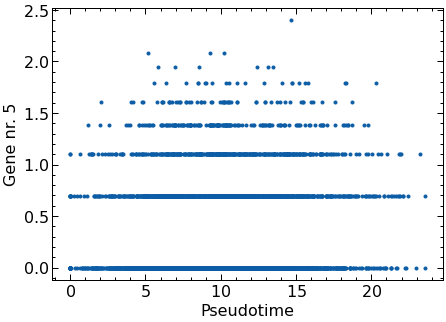

In [21]:
# plot one specific gene before ordering the points in the same manner
i_gene = 5

plt.figure(figsize=(7,5))
plt.plot(times_df['Calcium Signaling Pseudotime'], genes_df.T.iloc[1:,i_gene], '.')
plt.xlabel("Pseudotime")
plt.ylabel(f"Gene nr. {i_gene}")
plt.show()

Reorder points according to labels in gene dataset

In [24]:
labels_points = (genes_df.T).index[1:].values.astype(str)
print(labels_points.shape)

times_df = times_df.set_index('Sample').reindex(labels_points).reset_index()
print(times_df.shape)
times_df

(3969,)
(3969, 2)


,Sample,Calcium Signaling Pseudotime
0,EC2-AAACCTGAGGATGCGT,7.130266
1,EC2-AAAGCAAAGGTGTGGT,6.440417
2,EC2-AAAGCAACAGCTATTG,7.802815
3,EC2-AAATGCCAGAAGGTTT,6.156968
4,EC2-AAATGCCTCGCGCCAA,9.726252
...,...,...
3964,EC10-TTTGGTTCAAAGGTGC,9.348872
3965,EC10-TTTGGTTTCATCACCC,11.619342
3966,EC10-TTTGTCAAGAATAGGG,10.445863
3967,EC10-TTTGTCAAGACGACGT,10.181083


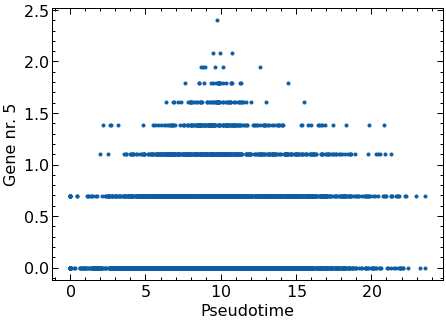

In [25]:
# plot one specific gene after ordering the points in the same manner
i_gene = 5

plt.figure(figsize=(7,5))
plt.plot(times_df['Calcium Signaling Pseudotime'], genes_df.T.iloc[1:,i_gene], '.')
plt.xlabel("Pseudotime")
plt.ylabel(f"Gene nr. {i_gene}")
plt.show()

In [26]:
# extract numpy arrays from pandas dataframes
times = times_df['Calcium Signaling Pseudotime'].to_numpy()
genes = (genes_df.T).iloc[1:,:].to_numpy(dtype=float)
print(times.shape, genes.shape)

(3969,) (3969, 228)


## Introduce noise to break degeneracy in the two spaces

In [13]:
# add noise to break neighbor degeneracies (both in gene and pseudotime spaces)
times += np.random.normal(loc=0., scale=1e-6, size=times.shape)
genes += np.random.normal(loc=0., scale=1e-6, size=genes.shape)

In [14]:
Counter(times)

Counter({1.700980881868184: 1,
         13.145694013529925: 1,
         3.424307500247192: 1,
         5.243402745298699: 1,
         8.186122847337678: 1,
         7.360355450332996: 1,
         5.760374365402503: 1,
         3.5624696162956027: 1,
         7.909165212694353: 1,
         10.729957855866353: 1,
         5.006117102246148: 1,
         8.244370841611518: 1,
         7.998192132792244: 1,
         6.7842840709558025: 1,
         10.131995097671563: 1,
         9.423006057717375: 1,
         4.696219318663488: 1,
         4.501894367105479: 1,
         13.728843633294238: 1,
         10.448051212234118: 1,
         10.979550199965859: 1,
         5.5475959760063205: 1,
         8.561459278160905: 1,
         10.288833536352016: 1,
         3.9789179510712493: 1,
         11.814773379566862: 1,
         10.512017003958553: 1,
         10.36723919497844: 1,
         6.450381182363255: 1,
         6.87739938521894: 1,
         6.3347808401099135: 1,
         8.08551794541589:

In [15]:
target_ranks_times = nns_index_array(times.reshape(-1,1), maxk=times.shape[0]-1)

KeyboardInterrupt: 

## Greedy selection of best variables

In [13]:
k = 1
n_coords = 30
n_best = 1
njobs = 4

d = MetricComparisons(genes, njobs=njobs)
variables, imbalances, _ = d.greedy_feature_selection_target(target_ranks=target_ranks_times, 
                                                          n_best=n_best,
                                                          n_coords=n_coords,
                                                          k=k,
                                                          symm=False)

total number of computations is:  228
total number of computations is:  227
total number of computations is:  226
total number of computations is:  225
total number of computations is:  224
total number of computations is:  223
total number of computations is:  222
total number of computations is:  221
total number of computations is:  220
total number of computations is:  219
total number of computations is:  218
total number of computations is:  217
total number of computations is:  216
total number of computations is:  215
total number of computations is:  214
total number of computations is:  213
total number of computations is:  212
total number of computations is:  211
total number of computations is:  210
total number of computations is:  209
total number of computations is:  208
total number of computations is:  207
total number of computations is:  206
total number of computations is:  205
total number of computations is:  204
total number of computations is:  203
total number

ValueError: too many values to unpack (expected 2)